In [38]:
#  Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import chi2_contingency


In [64]:
#Loading dataset

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Projects/rideshare_survey.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
#  Display of the dataset

df.columns = [
    'Age',
    'Gender',
    'Ride_Frequency',
    'Waiting_Time',
    'Distance',
    'Driver_Rating',
    'Cleanliness',
    'Ease_of_Booking',
    'Ride_Cost',
    'Time_of_Day',
    'Service_Rating'
]
display(df.head())

print("\nDataset Information:\n")
df.info()

print("\nShape of Dataset:")
print(df.shape)

,Age,Gender,Ride_Frequency,Waiting_Time,Distance,Driver_Rating,Cleanliness,Ease_of_Booking,Ride_Cost,Time_of_Day,Service_Rating
0,18,Male,Occasionally,11-20 minutes,21-30 km,4,Often,Easy,Neutral,Afternoon,4
1,22,Male,Rarely,Less than 5 minutes,21-30 km,4,Always,Easy,Neutral,Evening,4
2,20,Female,Occasionally,5-10 minutes,7-15 km,5,Always,Very easy,Affordable,Morning,5
3,20,Female,Occasionally,11-20 minutes,2-7 km,4,Sometimes,Very easy,Neutral,Evening,3
4,20,Male,Rarely,5-10 minutes,15-21 km,3,Sometimes,Very easy,Neutral,Afternoon,4



Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              153 non-null    int64 
 1   Gender           153 non-null    object
 2   Ride_Frequency   153 non-null    object
 3   Waiting_Time     153 non-null    object
 4   Distance         153 non-null    object
 5   Driver_Rating    153 non-null    int64 
 6   Cleanliness      153 non-null    object
 7   Ease_of_Booking  153 non-null    object
 8   Ride_Cost        153 non-null    object
 9   Time_of_Day      153 non-null    object
 10  Service_Rating   153 non-null    int64 
dtypes: int64(3), object(8)
memory usage: 13.3+ KB

Shape of Dataset:
(153, 11)


In [62]:
#Checking for missing value

df.isnull().sum()

,0
Age,0
Gender,0
Ride_Frequency,0
Waiting_Time,0
Distance,0
Driver_Rating,0
Cleanliness,0
Ease_of_Booking,0
Ride_Cost,0
Time_of_Day,0


In [57]:
#  checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [63]:
print(df['Gender'].unique())
print(df['Waiting_Time'].unique())
print(df['Distance'].unique())
print(df['Time_of_Day'].unique())
print(df['Cleanliness'].unique())
print(df['Ease_of_Booking'].unique())
print(df['Ride_Cost'].unique())
print(df['Ride_Frequency'].unique())

['Male' 'Female']
['11-20 minutes' 'Less than 5 minutes' '5-10 minutes'
 'More than 30 minutes' '21-30 minutes']
['21-30 km' '7-15 km' '2-7 km' '15-21 km' 'more than 30 km']
['Afternoon' 'Evening' 'Morning' 'Night']
['Often' 'Always' 'Sometimes' 'Never' 'Rarely']
['Easy' 'Very easy' 'Neutral' 'Difficult']
['Neutral' 'Affordable' 'Expensive' 'Very expensive' 'Very affordable']
['Occasionally' 'Rarely' 'Weekly' 'Daily' 'Monthly']


In [66]:



# Encoding gender categories into numerical values

gender_map = {
    'Male': 0,
    'Female': 1
}

df['Gender'] = df['Gender'].map(gender_map)

# Encoding waiting time categories from shortest to longest wait time

waiting_time_map = {
    'Less than 5 minutes': 1,
    '5-10 minutes': 2,
    '11-20 minutes': 3,
    '21-30 minutes': 4,
    'More than 30 minutes': 5
}

df['Waiting_Time'] = df['Waiting_Time'].map(waiting_time_map)

# Encoding travel distance categories from shortest to longest distance

distance_map = {
    '2-7 km': 1,
    '7-15 km': 2,
    '15-21 km': 3,
    '21-30 km': 4,
    'more than 30 km': 5
}

df['Distance'] = df['Distance'].map(distance_map)


# Encoding time of day from morning to night

time_map = {
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3,
    'Night': 4
}

df['Time_of_Day'] = df['Time_of_Day'].map(time_map)

# Encoding cleanliness from NEVER to ALWAYS

cleanliness_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

df['Cleanliness'] = df['Cleanliness'].map(cleanliness_map)

#Encoding Ease of booking from very easy to very difficult

ease_of_booking_map = {
    'Very easy': 1,
    'Easy': 2,
    'Neutral': 3,
    'Difficult': 4,
    'Very difficult': 5
}

df['Ease_of_Booking'] = df['Ease_of_Booking'].map(ease_of_booking_map)

# Encoding ride cost from very affordable to very expensive

ride_cost_map = {
    'Very affordable': 1,
    'Affordable': 2,
    'Neutral': 3,
    'Expensive': 4,
    'Very expensive': 5
}

df['Ride_Cost'] = df['Ride_Cost'].map(ride_cost_map)

# Encoding ride usage frequency from low to high frequency

frequency_map = {
    'Rarely': 1,
    'Occasionally': 2,
    'Monthly': 3,
    'Weekly': 4,
    'Daily': 5
}

df['Ride_Frequency'] = df['Ride_Frequency'].map(frequency_map)







df.head()

,Age,Gender,Ride_Frequency,Waiting_Time,Distance,Driver_Rating,Cleanliness,Ease_of_Booking,Ride_Cost,Time_of_Day,Service_Rating
0,18,0,2,3,4,4,4,2,3,2,4
1,22,0,1,1,4,4,5,2,3,3,4
2,20,1,2,2,2,5,5,1,2,1,5
3,20,1,2,3,1,4,3,1,3,3,3
4,20,0,1,2,3,3,3,1,3,2,4


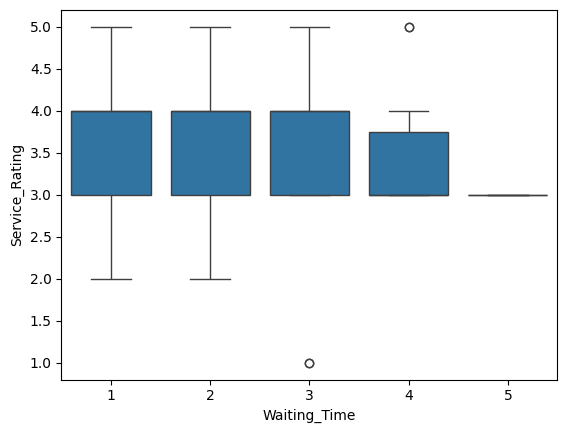

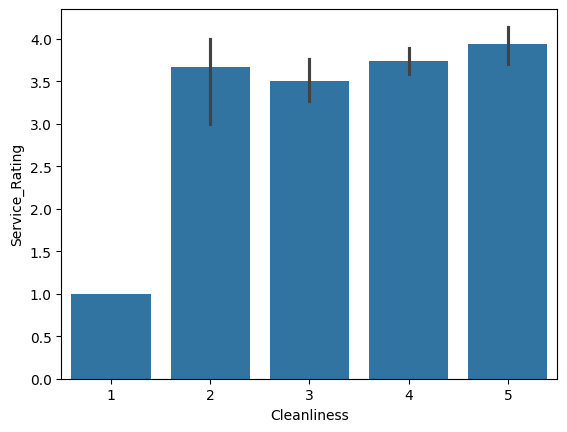

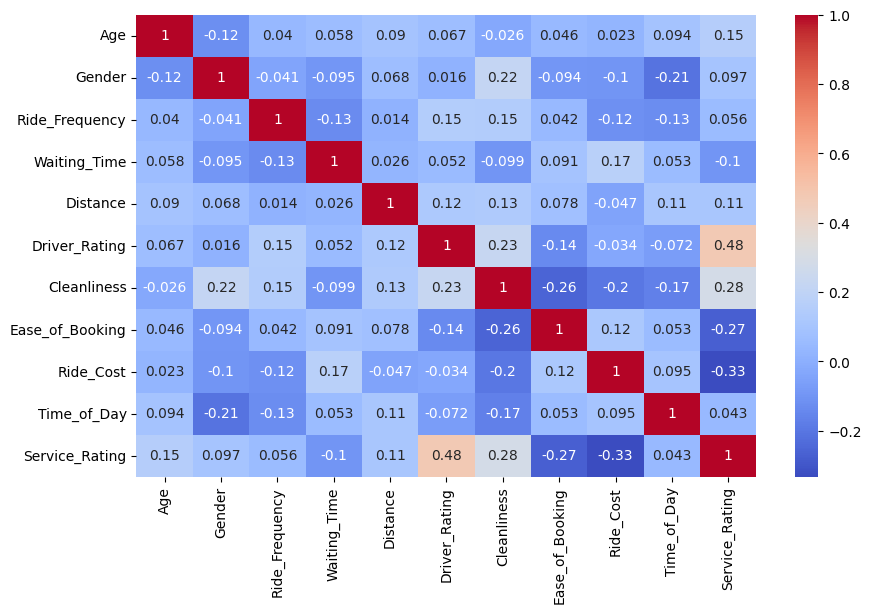

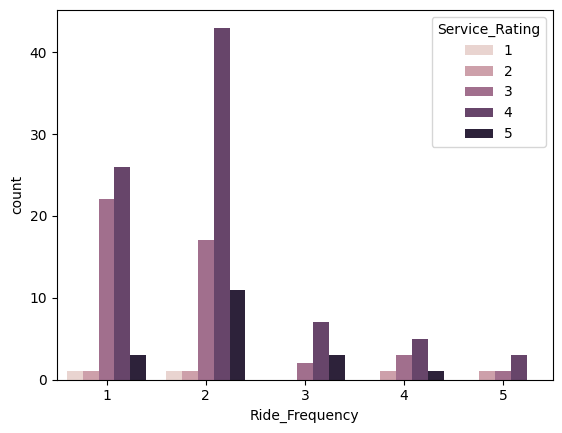

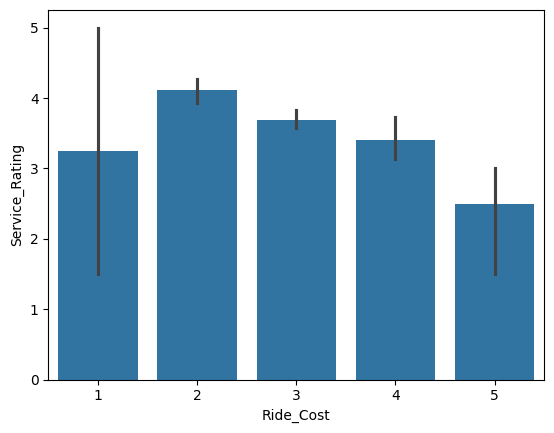

In [77]:
# Exploratory data analysis

# Does waiting time affect customer satisfaction?

sns.boxplot(x='Waiting_Time', y='Service_Rating', data=df)
plt.show()

#  Does cleanliness influence customer satisfaction?

sns.barplot(x='Cleanliness', y='Service_Rating', data=df)
plt.show()

# Which factors show strongest correlation?

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Does ride-sharing usage frequency influence customer satisfaction?

sns.countplot(x='Ride_Frequency', hue='Service_Rating', data=df)
plt.show()

#  Does perceived ride cost influence overall customer satisfaction?

sns.barplot(x='Ride_Cost', y='Service_Rating', data=df)
plt.show()



In [81]:
# Hypothesis Testing :
# H0 : Driver rating and service rating are independent.
# H1 : Driver rating significantly affects service rating.

contingency_table = pd.crosstab(df['Driver_Rating'], df['Service_Rating'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print('P-value:', p)


P-value: 8.389279504218833e-20


In [85]:
# Train-Test Split
# Separating input features and target variable

X = df.drop('Service_Rating', axis=1)
y = df['Service_Rating']


# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Checking dimensions of training and testing datasets

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(122, 10)
(31, 10)
(122,)
(31,)


In [88]:
# Model 1- Logistic Regression
# Building and training Logistic Regression model

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)


# Generating predictions using Logistic Regression

lr_pred = lr.predict(X_test)

# Calculating accuracy of Logistic Regression model

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

# Generating classification report for Logistic Regression model

from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

# Generating confusion matrix for Logistic Regression model

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

Logistic Regression Accuracy: 0.6129032258064516
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.58      0.58      0.58        12
           4       0.61      0.73      0.67        15
           5       1.00      0.33      0.50         3

    accuracy                           0.61        31
   macro avg       0.55      0.41      0.44        31
weighted avg       0.62      0.61      0.60        31

[[ 0  1  0  0]
 [ 0  7  5  0]
 [ 0  4 11  0]
 [ 0  0  2  1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Decision Tree Accuracy: 0.5483870967741935
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         1
           3       0.56      0.42      0.48        12
           4       0.61      0.73      0.67        15
           5       0.50      0.33      0.40         3

    accuracy                           0.55        31
   macro avg       0.33      0.30      0.31        31
weighted avg       0.56      0.55      0.55        31

[[ 0  0  0  0  0]
 [ 0  0  0  1  0]
 [ 1  1  5  5  0]
 [ 0  0  3 11  1]
 [ 0  0  1  1  1]]


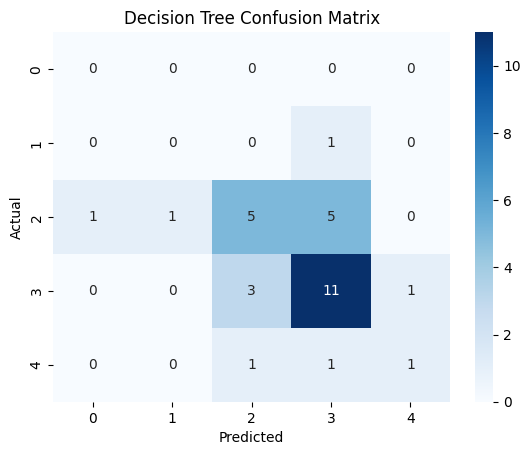

In [89]:
# Model 2- Decision Tree
# Building and training Decision Tree model

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)


# Generating predictions using Decision Tree

dt_pred = dt.predict(X_test)

# Calculating accuracy of Decision Tree model

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)


# Generating classification report for Decision Tree model

print(classification_report(y_test, dt_pred, zero_division=0))


# Generating confusion matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)


# Visualizing confusion matrix using heatmap

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

Random Forest Accuracy: 0.7096774193548387
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         1
           3       0.70      0.58      0.64        12
           4       0.70      0.93      0.80        15
           5       1.00      0.33      0.50         3

    accuracy                           0.71        31
   macro avg       0.60      0.46      0.48        31
weighted avg       0.71      0.71      0.68        31

[[ 0  1  0  0]
 [ 0  7  5  0]
 [ 0  1 14  0]
 [ 0  1  1  1]]


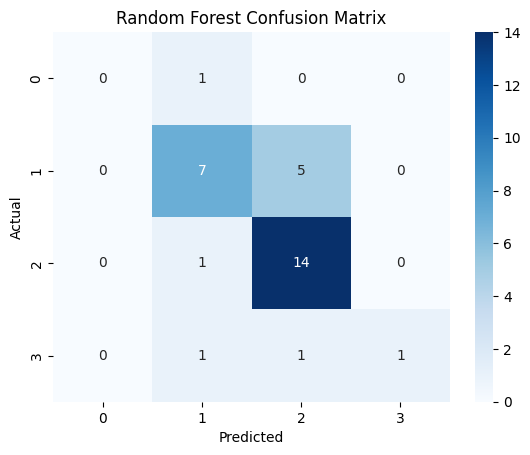

In [90]:
# Model 3- Random Forrest
# Building and training Random Forest model

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)


# Generating predictions using Random Forest

rf_pred = rf.predict(X_test)

# Calculating accuracy of Random Forest model

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)


# Generating classification report for Random Forest model

print(classification_report(y_test, rf_pred, zero_division=0))


# Generating confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)


# Visualizing confusion matrix using heatmap

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

Ride_Cost          0.142623
Driver_Rating      0.137444
Age                0.125898
Waiting_Time       0.103602
Cleanliness        0.098412
Ease_of_Booking    0.097576
Time_of_Day        0.095118
Distance           0.080424
Ride_Frequency     0.070660
Gender             0.048242
dtype: float64


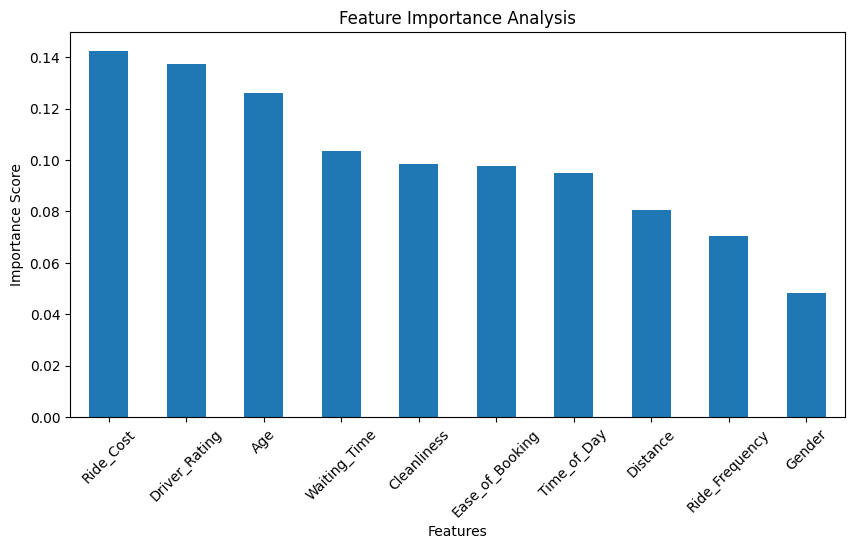

In [93]:
# Feature Importance Analysis using Random Forest


# Extracting feature importance scores from Random Forest model

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)


# Sorting feature importance values in descending order

importance = importance.sort_values(ascending=False)

print(importance)


# Visualizing feature importance using bar chart

importance.plot(kind='bar', figsize=(10,5))

plt.title("Feature Importance Analysis")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()
